# 2D Segmentation with TransUNet and the Datamint Trainer API

This notebook shows how to train a **TransUNet** semantic segmentation model on the **BUSI** (Breast Ultrasound Images) dataset using Datamint's **Trainer API**.

## What is TransUNet?

TransUNet (Chen et al., 2021) is a hybrid CNN + Transformer architecture for medical image segmentation. Unlike pure CNNs (UNet++, DeepLabV3+), it uses a **Vision Transformer (ViT)** as the bottleneck, which captures long-range dependencies that convolutions miss.

The architecture:
- **Encoder**: ResNet-50 extracts multi-scale feature maps → fed as tokens into a ViT-B/16 transformer
- **Skip connections**: 3 skip connections from the ResNet (at 1/2, 1/4, and 1/8 resolution)
- **Decoder**: 4-block Cascaded UPsampler (CUP) progressively restores full resolution

> Chen et al., "TransUNet: Transformers Make Strong Encoders for Medical Image Segmentation", arXiv:2102.04306 (2021)

TransUNet **requires 224×224 inputs**. The ViT positional embeddings are pre-trained for exactly 196 tokens (14×14 patches from a 224×224 image). This is different from UNet++ and DeepLabV3+, which accept arbitrary sizes.

## What You'll Learn

1. Upload BUSI data to Datamint
2. Train with `TransUNetTrainer` using zero configuration
3. Train with a custom external model via `SemanticSegmentation2DTrainer`
4. Visualise predictions
5. Register and deploy the trained model

## Required Dependencies

```bash
pip install datamint
```

In [2]:
from datamint import Api

PROJECT_NAME = "TransUNet_BUSI_Tutorial"
api = Api()

## 1. Setup: Create Project

In [3]:
proj = api.projects.create(
    name=PROJECT_NAME,
    description="TransUNet tutorial on BUSI breast ultrasound dataset",
    exists_ok=True,
)
proj

TransUNet_BUSI_Tutorial
2026-06-02T12:26:26.718Z
luandalmazo@gmail.com
False
0
TransUNet tutorial on BUSI breast ultrasound dataset


## 2. Dataset Preparation: Download and Upload BUSI

This section downloads the BUSI dataset and uploads it to Datamint.
If you already have the data inside Datamint, you can **skip to Section 3**.

### 2.1 Download BUSI Dataset

The BUSI dataset contains breast ultrasound images with pixel-level segmentation masks for benign and malignant lesions.

> Al-Dhabyani W, Gomaa M, Khaled H, Fahmy A. Dataset of breast ultrasound images. Data in Brief. 2020 Feb;28:104863. DOI: 10.1016/j.dib.2019.104863.

In [4]:
import os
import requests
import zipfile
from pathlib import Path

BUSI_URL = "https://www.kaggle.com/api/v1/datasets/download/sabahesaraki/breast-ultrasound-images-dataset"
DATA_DIR = Path("/tmp/BUSI_dataset")

if not DATA_DIR.exists():
    print("Downloading BUSI dataset...")
    response = requests.get(BUSI_URL, stream=True)
    response.raise_for_status()
    zip_path = DATA_DIR / "Dataset_BUSI.zip"
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    with open(zip_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    os.remove(zip_path)
    print("Download complete!")
else:
    print(f"Dataset already exists at {DATA_DIR}")

Extracting...
Download complete!


### 2.2 Find image and mask paths

In [7]:
base_dir = DATA_DIR / "Dataset_BUSI_with_GT"
classes = ["benign", "malignant", "normal"]

image_paths = []
label_paths = []

for cls in classes:
    cls_dir = base_dir / cls
    cls_images = sorted([p for p in cls_dir.glob("*.png") if "_mask" not in p.name])
    for img_p in cls_images:
        mask_p = cls_dir / f"{img_p.stem}_mask.png"
        if mask_p.exists():
            image_paths.append(img_p)
            label_paths.append(mask_p)

print(f"Found {len(image_paths)} images and {len(label_paths)} masks")

Found 780 images and 780 masks


### 2.3 Upload images and masks to Datamint

In [6]:
uploaded_resources = api.resources.upload_resources(
    [str(p) for p in image_paths],
    tags=['busi', 'ultrasound', 'breast'],
    publish_to=proj,
    progress_bar=True,
)
print(f"Uploaded {len(uploaded_resources)} images")

Uploading resources: 100%|██████████| 780/780 [04:09<00:00,  3.13file/s, file=normal (93).png]    


Uploaded 780 images


In [8]:
from tqdm.auto import tqdm

all_resources = list(api.resources.get_list(project_name=PROJECT_NAME, tags=['busi']))
filename_to_resource = {r.filename: r for r in all_resources}

for img_path, label_path in tqdm(zip(image_paths, label_paths), total=len(image_paths)):
    if 'normal' in img_path.parent.name:
        continue  # Normal images have no lesion masks
    resource = filename_to_resource[img_path.name]
    cls_name = img_path.parent.name  # 'benign' or 'malignant'

    api.annotations.upload_segmentations(
        resource=resource,
        file_path=label_path,
        name=cls_name,
        imported_from="Original GT BUSI Dataset",
    )

print("Segmentation masks uploaded successfully!")

100%|██████████| 780/780 [22:48<00:00,  1.75s/it]

Segmentation masks uploaded successfully!


### 2.4 Tag train/val/test splits

| Split | Percentage | Purpose |
|-------|------------|---------|
| Train | 70% | Model training |
| Validation | 15% | Early stopping |
| Test | 15% | Final evaluation |

In [9]:
import random

all_resources = list(api.resources.get_list(project_name=PROJECT_NAME, tags=['busi']))
all_resources.sort(key=lambda r: r.filename)

random.seed(42)
random.shuffle(all_resources)

n_total = len(all_resources)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_resources = all_resources[:n_train]
val_resources = all_resources[n_train:n_train + n_val]
test_resources = all_resources[n_train + n_val:]

api.projects.assign_splits(proj, train_resources, split_name='train')
api.projects.assign_splits(proj, val_resources, split_name='val')
api.projects.assign_splits(proj, test_resources, split_name='test')

print(f"Train: {len(train_resources)}, Val: {len(val_resources)}, Test: {len(test_resources)}")

Train: 546, Val: 117, Test: 117


## 3. Training with TransUNetTrainer

TransUNet requires very little configuration. The two things to keep in mind compared to `UNetPPTrainer` or `DeepLabV3PlusTrainer`:

1. **`image_size` is fixed at 224×224** — the ViT positional embeddings are pre-trained for this exact resolution. Any other value raises a `ValueError`.
2. **`batch_size=8` instead of 16** — the ViT-B transformer adds ~86M parameters on top of the ResNet-50 backbone, roughly 3× the memory footprint of UNet++.

Everything else — dataset loading, augmentation, loss, metrics, MLflow logging, checkpointing, deployment adapter — is handled automatically.

In [16]:
from datamint.lightning import TransUNetTrainer

import os
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

trainer = TransUNetTrainer(
    project=PROJECT_NAME,
    # image_size is omitted — TransUNetTrainer always uses 224×224.
    # Passing any other value raises a ValueError.
    batch_size=8,
    max_epochs=3,
    pretrained=True,   # loads ImageNet-21k pre-trained R50+ViT-B/16 weights
    accelerator='auto',
)


In [ ]:
results = trainer.fit()

In [18]:
print("Test results:")
for metric_dict in results['test_results']:
    for k, v in metric_dict.items():
        print(f"  {k}: {v:.4f}")

Test results:
  test/loss: 1.4895
  test/dice: 0.2703
  test/iou: 0.1795


### 3.1 Using a custom or external model

You can keep the Datamint trainer workflow and swap only the model architecture.
The example below wraps TransUNet inside a `SegmentationModule` manually, which is useful when you want to customise the loss or add extra logging while keeping Datamint-native deployment.

In [ ]:
from datamint.lightning import SemanticSegmentation2DTrainer
from datamint.lightning.trainers.lightning_modules import SegmentationModule
from datamint.lightning.trainers.lightning_modules.segmentation_modules import TransUNetModule


class MyTransUNetModel(SegmentationModule):
    def __init__(self, *args, **kwargs):
        super().__init__(*args,
                         class_names=['benign', 'malignant'],
                         **kwargs)
        from datamint.lightning.trainers.lightning_modules.segmentation_modules.transunet import _TransUNetModel
        self.model = _TransUNetModel(
            in_channels=3,
            num_classes=2,
            pretrained=True,
        )

    def forward(self, x):
        return self.model(x)


trainer = SemanticSegmentation2DTrainer(
    project=PROJECT_NAME,
    image_size=224,    # must be 224 when using TransUNet
    batch_size=8,
    early_stopping_patience=10,
    model=MyTransUNetModel,
    accelerator='auto',
)

In [ ]:
results = trainer.test(register_model=True)

## 4. Visualize Predictions

/home/luan/Desktop/Datamint/Codes/datamint-python-api/datamint/env/lib/python3.12/site-packages/albumentations/core/transforms_interface.py:310: UserWarning: The image is already an RGB.
  target_function(ensure_contiguous_output(arg), **params),


Sample 1 — IoU: 10.8% — Classes: ['benign', 'malignant']


/home/luan/Desktop/Datamint/Codes/datamint-python-api/datamint/env/lib/python3.12/site-packages/albumentations/core/transforms_interface.py:310: UserWarning: The image is already an RGB.
  target_function(ensure_contiguous_output(arg), **params),


Sample 11 — IoU: 0.0% — Classes: ['benign', 'malignant']


/home/luan/Desktop/Datamint/Codes/datamint-python-api/datamint/env/lib/python3.12/site-packages/albumentations/core/transforms_interface.py:310: UserWarning: The image is already an RGB.
  target_function(ensure_contiguous_output(arg), **params),


Sample 42 — IoU: 21.2% — Classes: ['benign', 'malignant']


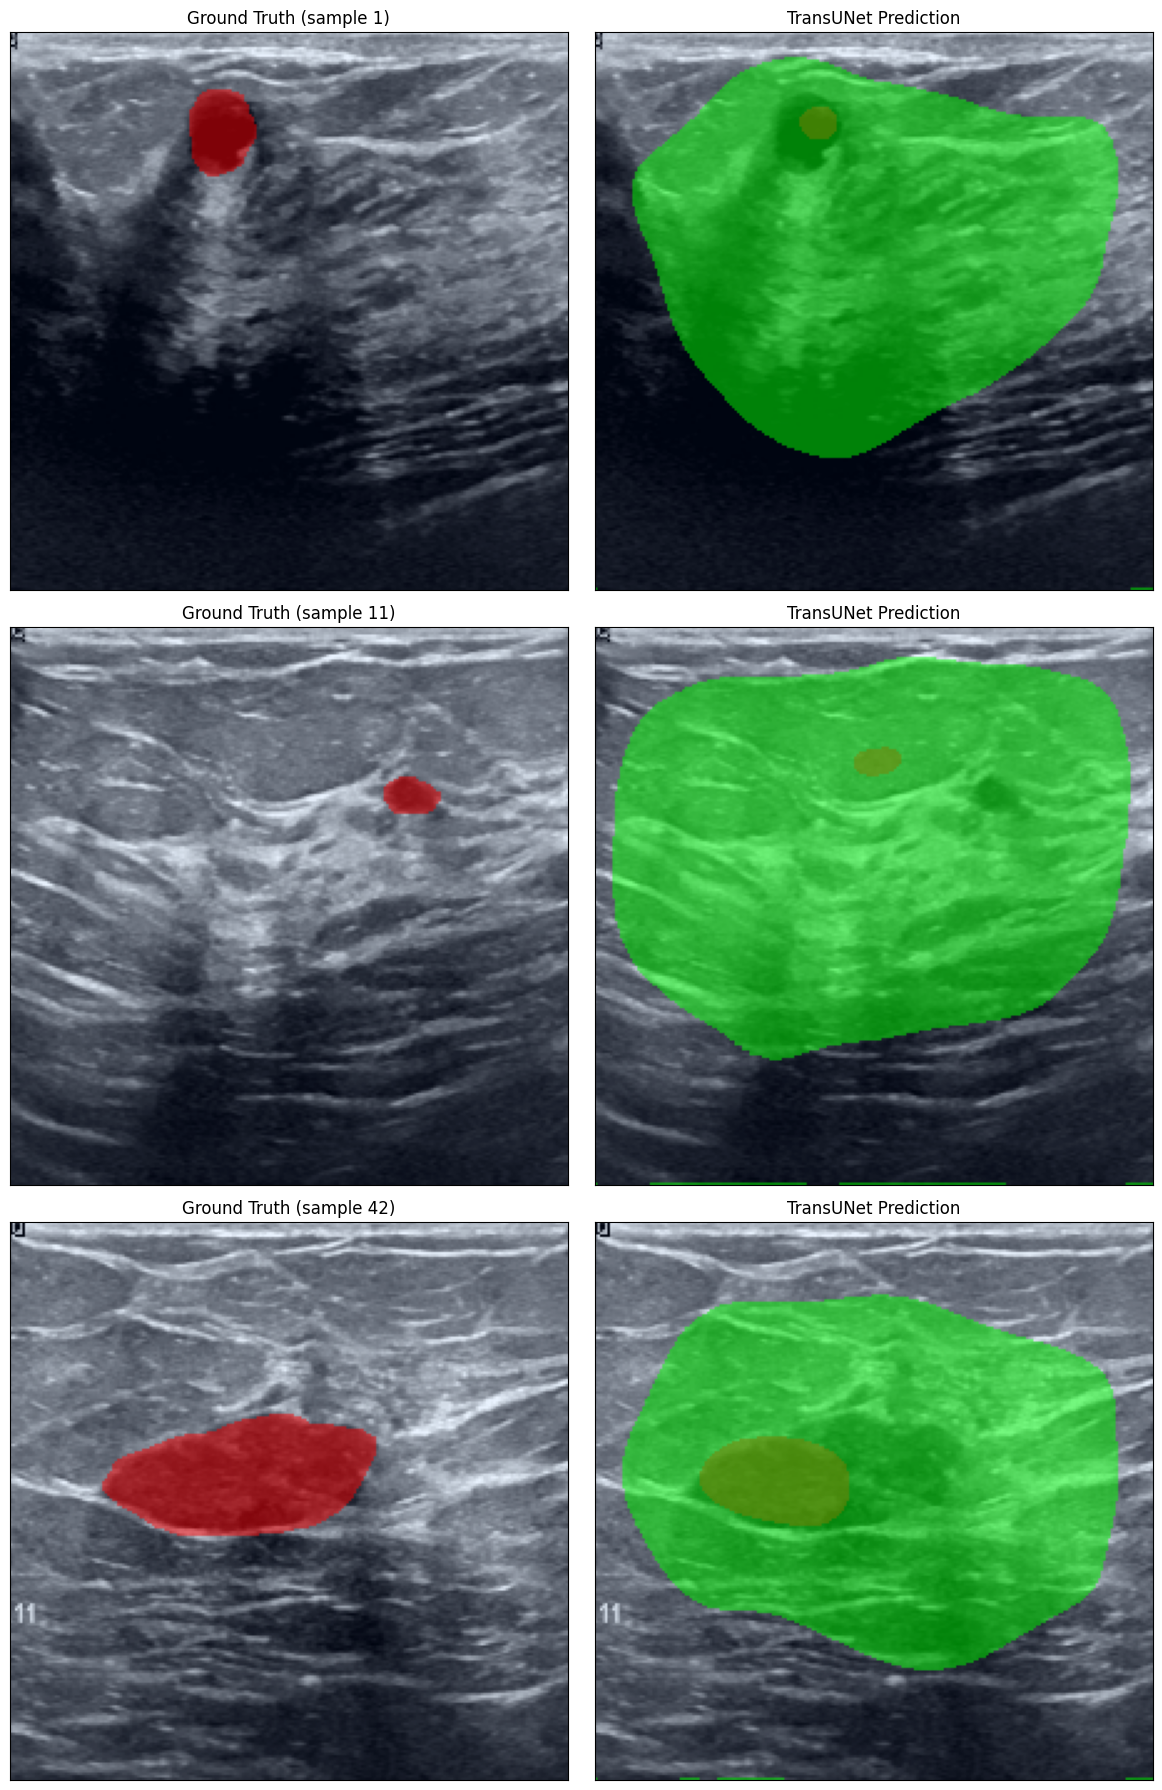

In [19]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from datamint.utils.visualization import show, draw_masks
from torchmetrics.functional.segmentation import mean_iou

model = trainer.model
model.eval()

test_dataset = trainer.datamodule.test_dataloader().dataset
class_names = trainer.datamodule.dataset.seglabel_list

fig, axes = plt.subplots(3, 2, figsize=(12, 18))

for row in range(3):
    idx = np.random.choice(len(test_dataset))
    sample = test_dataset[idx]
    image = sample['image']            # (C, H, W)
    mask_gt = sample['segmentations']  # (#classes+1, H, W)

    with torch.inference_mode():
        logits = model(image.unsqueeze(0).to(model.device))
        mask_pred = (logits[0] > 0).cpu()

    gt_overlay = draw_masks(image, mask_gt[1:], alpha=0.5)
    axes[row, 0].set_title(f"Ground Truth (sample {idx})")
    show(gt_overlay, ax=axes[row, 0])

    pred_overlay = draw_masks(image, mask_pred, alpha=0.5)
    axes[row, 1].set_title("TransUNet Prediction")
    show(pred_overlay, ax=axes[row, 1])

    iou = mean_iou(
        mask_pred.unsqueeze(0).long(),
        mask_gt[1:].unsqueeze(0).long(),
        num_classes=len(class_names),
        input_format='one-hot',
    )
    print(f"Sample {idx} — IoU: {iou.max():.1%} — Classes: {class_names}")

plt.tight_layout()
plt.show()

## 5. Customization Options

### 5.1 Pretrained vs. random initialization

```python
# Use ImageNet-21k pre-trained R50+ViT-B/16 weights (default, recommended)
trainer = TransUNetTrainer(
    project=PROJECT_NAME,
    pretrained=True,
)

# Train from scratch — useful for ablation studies
trainer = TransUNetTrainer(
    project=PROJECT_NAME,
    pretrained=False,
)
```

### 5.2 Custom loss

```python
import torch

trainer = TransUNetTrainer(
    project=PROJECT_NAME,
    loss_fn=torch.nn.BCEWithLogitsLoss(),
)
```

### 5.3 Custom augmentation pipeline

When overriding transforms, keep `A.Resize(224, 224)` — omitting it will cause a shape mismatch at the ViT positional embedding.

```python
import albumentations as A
from albumentations.pytorch import ToTensorV2

my_transforms = A.Compose([
    A.Resize(224, 224),   # required for TransUNet
    A.CLAHE(p=0.3),       # useful for ultrasound contrast enhancement
    A.Normalize(),
    ToTensorV2(),
])

trainer = TransUNetTrainer(
    project=PROJECT_NAME,
    train_transform=my_transforms,
)
```

### 5.4 Mixed precision and gradient accumulation

TransUNet benefits more from these than pure CNNs because of the attention layers.

```python
trainer = TransUNetTrainer(
    project=PROJECT_NAME,
    batch_size=4,
    trainer_kwargs={
        'precision': '16-mixed',       # halves VRAM usage for attention layers
        'accumulate_grad_batches': 4,  # effective batch size = 4×4 = 16
        'gradient_clip_val': 1.0,
    },
)
```

### 5.5 Note on encoder backbone

Unlike `UNetPPTrainer` and `DeepLabV3PlusTrainer`, `TransUNetTrainer` has **no `encoder_name` parameter**. The backbone is fixed to `R50-ViT-B_16` (ResNet-50 + ViT-Base/16). 

## 6. Deployment

The trainer automatically registered a deployment adapter in MLflow. You can deploy it directly to the Datamint server:

In [20]:
job = api.deploy.start(
    model_name=PROJECT_NAME,
    model_alias="latest",
    with_gpu=False,
)

print(f"Deployment job started!")
print(f"Job ID: {job.id}")
print(f"Status: {job.status}")

Deployment job started!
Job ID: 5f9c6d72-55dc-4ee9-a0b0-2c1c1abe32e1
Status: running


In [25]:
job = api.deploy.get_by_id(job.id)
print(f"Job Status: {job.status}")
print(f"Progress: {job.progress_percentage}%")
if job.error_message:
    print(f"Error: {job.error_message}")

Job Status: completed
Progress: 100%


### 6.1 Remote Inference

In [ ]:
r = api.resources.get_list(project_name=PROJECT_NAME, limit=1)[0]

inf_job = api.inference.submit(
    model_name=PROJECT_NAME,
    model_alias="latest",
    resource_id=r.id,
)
inf_job.wait()

In [ ]:
from matplotlib import pyplot as plt

preds = inf_job.predictions[0]
plt.figure(figsize=(6, 6))
plt.imshow(preds[0].mask, cmap='gray')
plt.title("TransUNet Predicted Mask")
plt.axis('off')

In [ ]:
proj.show()